Training Proposed Model via Soft Prompt Tuning...
Epoch 05/15 | Training Loss: 0.6981
Epoch 10/15 | Training Loss: 0.6963
Epoch 15/15 | Training Loss: 0.6943

Training Baseline Model via Traditional Full Tuning...
Epoch 05/15 | Training Loss: 3.0444
Epoch 10/15 | Training Loss: 1.1643
Epoch 15/15 | Training Loss: 0.6883

PARAMETER FOOTPRINT ANALYSIS
Total Model Parameters     : 70,514
Full Fine-Tuning Trainable : 70,386
Soft Prompt Tuning Trainable: 128
Parameters Frozen          : 70,386
Trainable Parameters %     : 0.182%


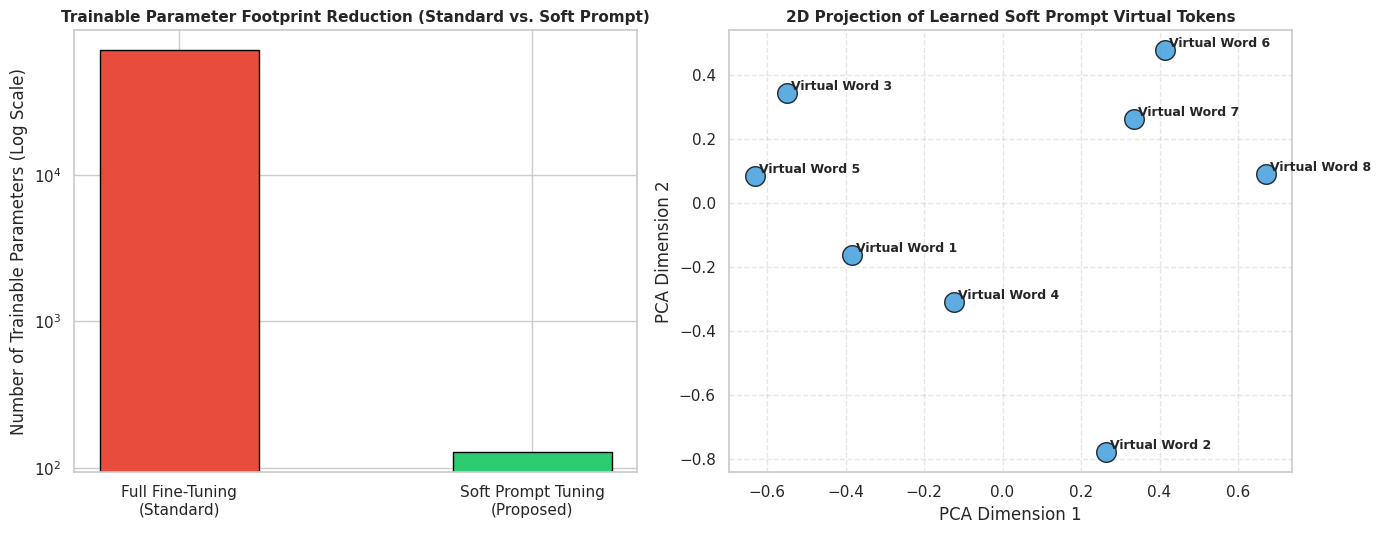

In [ ]:
# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.optim as optim  # weight adjusters
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling
from sklearn.decomposition import PCA  # dimensionality reducer

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Soft Prompt Transformer Architecture
# ==========================================

class SoftPromptTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, prompt_len, num_classes): # SoftPromptTransformer: Learns trainable virtual tokens (prompt_embeddings) prepended to input, while freezing the Transformer backbone - only prompt parameters update during training.
        super().__init__()
        self.prompt_len = prompt_len  # prompt length
        self.embed = nn.Embedding(vocab_size, embed_dim)  # token embedder

        # Trainable soft prompt parameter matrix (The virtual tokens)
        self.prompt_embeddings = nn.Parameter(torch.randn(1, prompt_len, embed_dim) * 0.1)

        # Frozen Transformer Backbone
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)  # transformer blocks
        self.classifier = nn.Linear(embed_dim, num_classes)  # linear classifier head

    def freeze_backbone(self):  # freeze method - freeze_backbone: Disables gradients for embedding, transformer, and classifier - only soft prompts remain trainable, reducing parameters dramatically.
        for param in self.embed.parameters():  # loop embedding
            param.requires_grad = False  # freeze parameter
        for param in self.transformer.parameters():  # loop transformer
            param.requires_grad = False  # freeze parameter
        for param in self.classifier.parameters():  # loop classifier
            param.requires_grad = False  # freeze parameter

    def unfreeze_all(self):  # unfreeze method for traditional tuning - unfreeze_all: Enables gradients for all parameters - full fine-tuning baseline. Disables prompts to compare standard training vs soft prompt tuning.
        for param in self.parameters():  # loop all params
            param.requires_grad = True  # unfreeze parameter
        self.prompt_embeddings.requires_grad = False  # turn off prompts for traditional comparison

    def forward(self, x):  # feedforward graph - Forward: Gets batch size, converts input tokens to word embeddings via embedding layer.
        batch_size = x.size(0)  # get batch size
        word_embeddings = self.embed(x)  # compute word embeddings

        # Prepend trainable soft prompt vectors to word inputs
        if self.prompt_embeddings.requires_grad or not self.embed.weight.requires_grad:
            prompts = self.prompt_embeddings.expand(batch_size, -1, -1)  # expand prompts batch
            x_combined = torch.cat([prompts, word_embeddings], dim=1)  # prepend prompts
        else:
            x_combined = word_embeddings  # standard inputs pass

        features = self.transformer(x_combined)  # pass through transformer
        pooled = features.mean(dim=1)  # mean pool outputs
        return self.classifier(pooled)  # return logits

# ==========================================
# Data Generation & Pipeline Comparison
# ==========================================

# Generate 128 synthetic sequence tokens (vocab size 100, length 10)
X_train = torch.randint(0, 100, (128, 10))  # train tokens
y_train = torch.randint(0, 2, (128,))  # binary targets

# 1. Initialize & Train Soft Prompt Tuning (Proposed)
model_prompt = SoftPromptTransformer(vocab_size=100, embed_dim=16, num_heads=2, num_layers=1, prompt_len=8, num_classes=2) # SoftPromptTransformer: Initializes model with 100 vocab size, 16-dim embeddings, 2 heads, 1 layer, 8 prompt tokens, 2 output classes.
model_prompt.freeze_backbone()  # freeze backbone weights
model_prompt.prompt_embeddings.requires_grad = True  # update only prompt parameter

optimizer_p = optim.Adam([model_prompt.prompt_embeddings], lr=0.05)  # prompt optimizer - Prompt Optimizer: Adam optimizer only for prompt embeddings (lr=0.05) - updates just 8 virtual tokens while backbone stays frozen.
criterion = nn.CrossEntropyLoss()  # loss objective - CrossEntropyLoss: Standard loss for multi-class classification - combines log-softmax and negative log-likelihood.

print("Training Proposed Model via Soft Prompt Tuning...")  # status log
for epoch in range(15):  # loop epochs
    outputs = model_prompt(X_train)  # forward pass
    loss = criterion(outputs, y_train)  # loss check
    optimizer_p.zero_grad()  # clean grads
    loss.backward()  # backpropagation
    optimizer_p.step()  # update prompt params
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/15 | Training Loss: {loss.item():.4f}")

# 2. Initialize & Train Traditional Tuning (Baseline comparison)
model_full = SoftPromptTransformer(vocab_size=100, embed_dim=16, num_heads=2, num_layers=1, prompt_len=8, num_classes=2) # SoftPromptTransformer: Initializes full fine-tuning baseline with same architecture - all parameters trainable (unfrozen) for comparison.
model_full.unfreeze_all()  # unfreeze standard parameters

optimizer_f = optim.Adam(model_full.parameters(), lr=0.01)  # standard optimizer

print("\nTraining Baseline Model via Traditional Full Tuning...")  # status log
# Full Tuning: Trains all model parameters for 15 epochs - updates every weight via backprop, showing standard fine-tuning approach.
for epoch in range(15):  # loop epochs
    outputs = model_full(X_train)  # forward pass
    loss = criterion(outputs, y_train)  # loss check
    optimizer_f.zero_grad()  # clean grads
    loss.backward()  # backpropagation
    optimizer_f.step()  # update model weights
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/15 | Training Loss: {loss.item():.4f}")

# ==========================================
# Audit Parameter Footprint
# ==========================================

# Calculate parameter counts
params_prompt = sum(p.numel() for p in model_prompt.parameters() if p.requires_grad)  # sum trainable params
params_full = sum(p.numel() for p in model_full.parameters() if p.requires_grad)  # sum standard params
total_backbone_params = sum(p.numel() for p in model_prompt.parameters())  # sum total params

print("\n=====================================")
print("PARAMETER FOOTPRINT ANALYSIS")
print("=====================================")
print(f"Total Model Parameters     : {total_backbone_params:,}")
print(f"Full Fine-Tuning Trainable : {params_full:,}")
print(f"Soft Prompt Tuning Trainable: {params_prompt:,}")
print(f"Parameters Frozen          : {total_backbone_params - params_prompt:,}")
print(f"Trainable Parameters %     : {(params_prompt / total_backbone_params) * 100:.3f}%")  # percent savings
print("=====================================")

# ==========================================
# Visualizations
# ==========================================

sns.set_theme(style="whitegrid")  # set theme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))  # build double canvas

# Left plot: Parameter Comparison Chart
categories = ['Full Fine-Tuning\n(Standard)', 'Soft Prompt Tuning\n(Proposed)']
counts = [params_full, params_prompt]
ax1.bar(categories, counts, color=['#e74c3c', '#2ecc71'], width=0.45, edgecolor='black')  # draw bars
ax1.set_yscale('log')  # logarithmic scale
ax1.set_ylabel('Number of Trainable Parameters (Log Scale)')
ax1.set_title('Trainable Parameter Footprint Reduction (Standard vs. Soft Prompt)', fontsize=11, fontweight='bold')

# Right plot: PCA projection of virtual token embeddings
pca = PCA(n_components=2)  # dimension reducer
prompts_np = model_prompt.prompt_embeddings.detach().squeeze(0).numpy()  # extract numpy prompt matrix
prompts_pca = pca.fit_transform(prompts_np)  # compress dimensions

ax2.scatter(prompts_pca[:, 0], prompts_pca[:, 1], color='#3498db', s=200, edgecolor='black', alpha=0.8, zorder=3)  # draw points
for i in range(len(prompts_pca)):
    ax2.annotate(f"Virtual Word {i+1}", (prompts_pca[i, 0] + 0.01, prompts_pca[i, 1] + 0.01), fontsize=9, fontweight='bold')  # draw label
ax2.set_xlabel('PCA Dimension 1')
ax2.set_ylabel('PCA Dimension 2')
ax2.set_title('2D Projection of Learned Soft Prompt Virtual Tokens', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()  # fit components
plt.show()  # display plots